In [275]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize, medial_axis
from scipy import ndimage

In [276]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [277]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


In [278]:
def get_canny_edges_auto(grey, sigma=0.33, debug=True, title="Canny Edges (Auto)"):

    # Estimate noise level using median
    v = np.median(grey)

    # Automatic thresholds
    low  = int(max(0, (1.0 - sigma) * v))
    high = int(min(255, (1.0 + sigma) * v))

    edges = cv2.Canny(grey, low, high)

    if debug:
        plt.figure(figsize=(8, 8))
        plt.imshow(edges, cmap="gray")
        plt.title(f"{title} (low={low}, high={high})")
        plt.axis("off")

    return edges


21.png from the hard set


(np.float64(-0.5), np.float64(1099.5), np.float64(732.5), np.float64(-0.5))

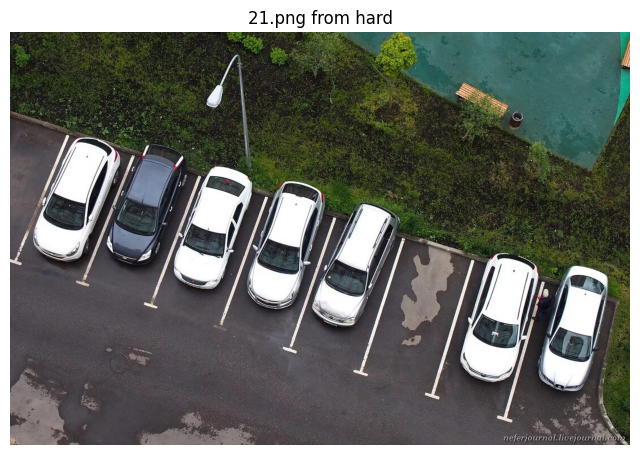

In [574]:
# --- EASY
#(set_name, image_name) = ("easy", "29.png")
#(set_name, image_name) = ("easy", "not_that_easy.jpg")
#(set_name, image_name) = ("easy", "easy.jpg")
#(set_name, image_name) = ("easy", "20.png")

# --- MEDIUM
#(set_name, image_name) = ("medium", "12.png")
#(set_name, image_name) = ("medium", "30.png")
#(set_name, image_name) = ("medium", "31.png")

# --- HARD
#(set_name, image_name) = ("hard", "frame600.jpg")
#(set_name, image_name) = ("hard", "frame1.jpg")
(set_name, image_name) = ("hard", "21.png")



print(f"{image_name} from the {set_name} set")
img = images[set_name][image_name]
image = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"{image_name} from {set_name}")
plt.axis("off")

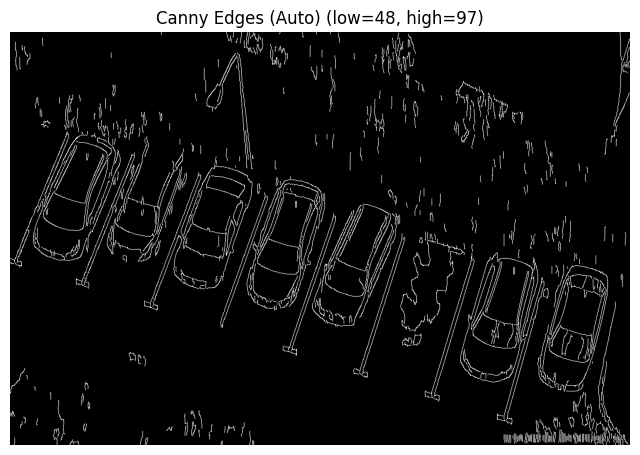

In [575]:
img_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(img_grey, (3,21), 0)
canny_output = get_canny_edges_auto(blurred)

In [576]:
def cluster_vertical_lines(lines, distance_thresh=20):
    """
    Takes Hough lines and merges vertical-ish lines into averaged lines.
    distance_thresh: max |rho difference| allowed in the same cluster.
    Preserves the actual slanted angle instead of forcing theta = 0.
    """
    vertical_rhos = []
    vertical_thetas = []

    # Extract vertical-ish lines
    for line in lines:
        rho, theta = line

        # Allow angles within ±20° of vertical
        if theta < np.deg2rad(50) or theta > np.deg2rad(160):
            vertical_rhos.append(rho)
            vertical_thetas.append(theta)

    if not vertical_rhos:
        return []

    # Sort by rho
    idx = np.argsort(vertical_rhos)
    rhos_sorted = np.array(vertical_rhos)[idx]
    thetas_sorted = np.array(vertical_thetas)[idx]

    clusters = []
    current_rhos = [rhos_sorted[0]]
    current_thetas = [thetas_sorted[0]]

    for r, t in zip(rhos_sorted[1:], thetas_sorted[1:]):
        if abs(r - current_rhos[-1]) < distance_thresh:
            current_rhos.append(r)
            current_thetas.append(t)
        else:
            clusters.append((current_rhos, current_thetas))
            current_rhos = [r]
            current_thetas = [t]

    clusters.append((current_rhos, current_thetas))

    # Average lines in each cluster
    merged = []
    for rhos, thetas in clusters:
        avg_rho = np.mean(rhos)

        # Normalise angles first so they average correctly
        thetas_norm = [normalise_angle(t) for t in thetas]
        avg_theta_norm = np.mean(thetas_norm)

        # Convert back to full range (0 to pi)
        if avg_theta_norm < 0:
            avg_theta = avg_theta_norm + np.pi
        else:
            avg_theta = avg_theta_norm

        merged.append((avg_rho, avg_theta))

    return merged

In [577]:
def normalise_angle(theta):
    # Convert to orientation angle (0–π) but symmetric
    return theta if theta < np.pi/2 else theta - np.pi

In [578]:
def modal_angle(angles, bin_size_deg=2):
    if len(angles) == 0:
        return None

    bin_size = np.deg2rad(bin_size_deg)
    bins = np.arange(-np.pi/2, np.pi/2 + bin_size, bin_size)

    hist, edges = np.histogram(angles, bins=bins)
    idx = np.argmax(hist)

    # modal angle = center of bin
    modal = (edges[idx] + edges[idx + 1]) / 2
    return modal


In [579]:
def filter_by_modal_angle(lines, angle_tolerance_deg=5):

    if not lines:
        return []

    # Extract normalised angles
    angs = [normalise_angle(theta) for (rho, theta) in lines]

    # Find modal orientation
    modal = modal_angle(angs)
    if modal is None:
        return []

    tol = np.deg2rad(angle_tolerance_deg)

    filtered = []
    for (rho, theta) in lines:
        ang = normalise_angle(theta)
        if abs(ang - modal) < tol:
            filtered.append((rho, theta))

    return filtered


In [580]:
def line_to_rho_theta(x1, y1, x2, y2):
    angle = np.arctan2((y2 - y1), (x2 - x1))
    theta = angle + np.pi/2

    # midpoint of the segment
    x0 = (x1 + x2) / 2
    y0 = (y1 + y2) / 2

    rho = x0 * np.cos(theta) + y0 * np.sin(theta)

    return rho, theta


(np.float64(-0.5), np.float64(1099.5), np.float64(732.5), np.float64(-0.5))

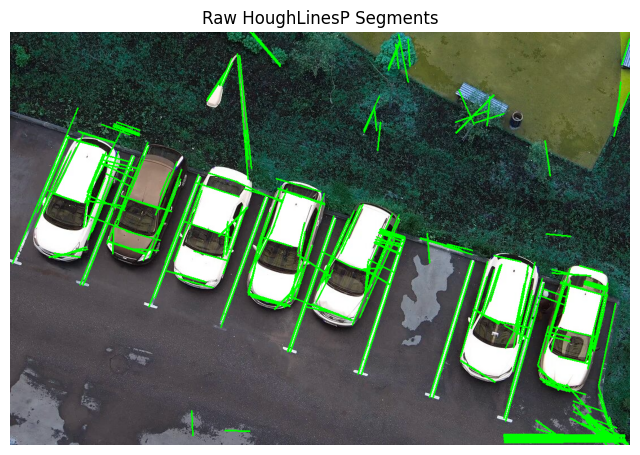

In [581]:
# Hough transform (probabilistic)
linesP = cv2.HoughLinesP(
    canny_output,
    rho=1,
    theta=np.pi/180,
    threshold=50,
    minLineLength=40,
    maxLineGap=15
)

# Copy image for drawing
houghP_vis = image.copy()

# Draw detected segments
if linesP is not None:
    for (x1, y1, x2, y2) in linesP[:,0]:
        cv2.line(houghP_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(houghP_vis)
plt.title("Raw HoughLinesP Segments")
plt.axis("off")


(np.float64(-0.5), np.float64(1099.5), np.float64(732.5), np.float64(-0.5))

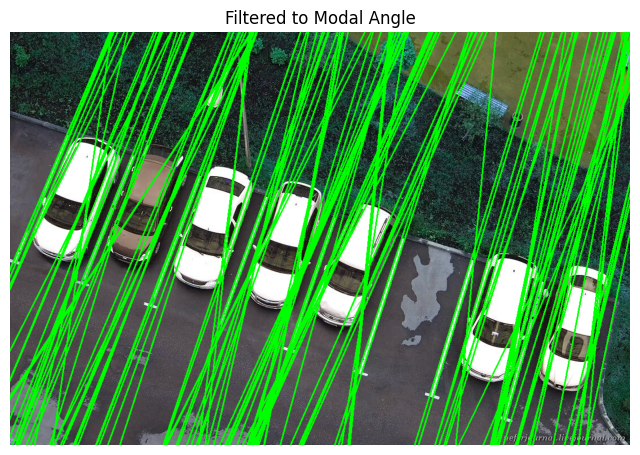

In [582]:
# Copy image for drawing
hough_lines = image.copy()

horiz_center = np.pi / 2               # 90 degrees
horiz_thresh = np.deg2rad(45)          # ±45 degrees

non_horiz = []

if linesP is not None:
    for (x1, y1, x2, y2) in linesP[:,0]:
        rho, theta = line_to_rho_theta(x1, y1, x2, y2)

        # apply same horizontal filtering
        if abs(theta - horiz_center) >= horiz_thresh:
            non_horiz.append((rho, theta))

# Filter by modal vertical-ish angle
filtered_lines = filter_by_modal_angle(non_horiz, angle_tolerance_deg=20)

# Draw filtered lines
hough_lines = image.copy()

for (rho, theta) in filtered_lines:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho

    x1 = int(x0 + 2000 * (-b))
    y1 = int(y0 + 2000 * (a))
    x2 = int(x0 - 2000 * (-b))
    y2 = int(y0 - 2000 * (a))

    cv2.line(hough_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(hough_lines)
plt.title("Filtered to Modal Angle")
plt.axis("off")

(np.float64(-0.5), np.float64(889.5), np.float64(203.5), np.float64(-0.5))

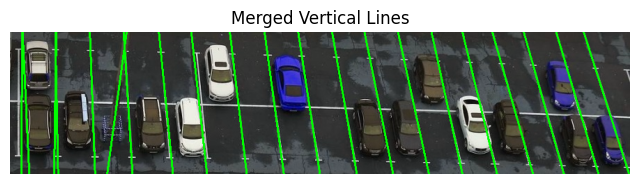

In [547]:
merged_verticals = cluster_vertical_lines(filtered_lines, distance_thresh=20)

# Draw on copy
merged_vis = image.copy()

for rho, theta in merged_verticals:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho

    x1 = int(x0 + 2000 * (-b))
    y1 = int(y0 + 2000 * (a))
    x2 = int(x0 - 2000 * (-b))
    y2 = int(y0 - 2000 * (a))

    cv2.line(merged_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(8,8))
plt.imshow(merged_vis)
plt.title("Merged Vertical Lines")
plt.axis("off")

In [487]:
def modal_vertical_spacing(merged_verticals, bin_size=5):
    """
    merged_verticals: list of (rho, theta)
    bin_size: histogram bin width for mode estimation
    
    Returns: modal_spacing
    """
    # Extract rho values
    rhos = sorted([rho for rho, theta in merged_verticals])

    if len(rhos) < 2:
        return None  # not enough lines for spacing

    # Compute distances between consecutive vertical lines
    spacings = []
    for i in range(1, len(rhos)):
        spacings.append(abs(rhos[i] - rhos[i - 1]))

    # Estimate mode via histogram (robust even without SciPy)
    if len(spacings) == 0:
        return None

    # Create histogram
    spacings = np.array(spacings)
    max_spacing = np.max(spacings)
    bins = np.arange(0, max_spacing + bin_size, bin_size)

    hist, edges = np.histogram(spacings, bins=bins)

    # Mode = center of highest bin
    modal_index = np.argmax(hist)
    modal_spacing = (edges[modal_index] + edges[modal_index + 1]) / 2

    return modal_spacing

In [488]:
modal_dist = modal_vertical_spacing(merged_verticals, bin_size=5)
print("Modal vertical spacing:", modal_dist)

Modal vertical spacing: 27.5


In [462]:
# Function to do the pipeline on the whole image.
def do_pipeline(images_array, set_name, image_name):

    # grab the image from the array.    
    img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    
    
    # angle = fast_dominant_line_angle(img_grey, name="Greyscale Skeleton Test")
    # rotated, M, Minv, valid_mask = rotate_image_with_reflect(img_grey, angle)
    #
    # plt.figure(figsize=(8,8))
    # plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    # plt.title("Rotated")
    # plt.axis("off")
    blurred = cv2.GaussianBlur(img_grey, (5,5), 0)
    # # --- Directional Morphology (Opening) ---
    horiz_lines = directional_open(
        blurred, horizon=True, ksize=40, name="Horizontal Opening"
    )

    vert_lines = directional_open(
        blurred, horizon=False, ksize=50, name="Vertical Opening"
    )

    canny_output_vert = get_canny_edges_auto(vert_lines)
    # --- Top-Hat Enhancement ---
    vertical_tophat = do_tophat(
        vert_lines, (40, 1), name="Vertical Tophat Test"
    )
    horizon_tophat = do_tophat(
        horiz_lines, (3, 40), name="Horizontal Tophat Test"
    )

    # --- Clean Top-Hat Output ---
    horizon_clean = clean_tophat(
        horizon_tophat, False, name="Tophat Horizon Cleaned"
    )
    vertical_clean = clean_tophat(
        vertical_tophat, True, name="Tophat Vertical Cleaned"
    )
    binarised = binarise(vertical_clean)
    subtract_canny_from_binarised(canny_output, binarised)
    
    horizon_lines = lsd_detect_and_show(horizon_clean, debug=True)
    vertical_lines = lsd_detect_and_show(vertical_clean, debug=True)

    print("Before filtering:", len(vertical_lines))
    filtered_lines = filter_bottom_quarter_by_length(vertical_lines)
    print("After filtering:", len(filtered_lines))

    
    # plt.figure(figsize=(8, 8))
    # plt.imshow(vis)
    # plt.title("LSD Filtered")
    # plt.axis("off")
    # plt.show()
    
    return

In [463]:
# --- EASY

#do_pipeline(images, "easy", "29.png")
#do_pipeline(images, "easy", "not_that_easy.jpg")
#do_pipeline(images, "easy", "easy.jpg")
do_pipeline(images, "easy", "20.png")

# --- Medium 
#do_pipeline(images, "medium", "12.png")
#do_pipeline(images, "medium", "30.png") # Slanted
#do_pipeline(images, "medium", "31.png")

# -- Hard
#do_pipeline(images, "hard", "frame600.jpg")
#do_pipeline(images, "hard", "frame1.jpg")
#do_pipeline(images, "hard", "21.png")

error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'
